# Alpha Benchmark Study (S&P 100 vs `^OEX`)

This notebook:

1. Loads daily OHLCV for S&P 100 names via yfinance-backed `finTs`, and **quarterly statement fundamentals** via `YFinanceFundamentalDataProvider` (all `FUNDAMENTAL_FIELDS` columns; `Price_To_Earnings` / `Free_Cash_Flow_Yield` stay NaN without a price merge).
2. Previews the period-end fundamental panel (head, describe, non-null counts).
3. Plots universe return behavior.
4. Runs all alphas from `examples/alphas` (including `fundamental_quality_yf`) through `FinStrat` + `FinBT`.
5. Compares each alpha against `^OEX` (S&P 100 benchmark).
6. Plots cross-correlation (`alphas <-> benchmark` and `alphas <-> alphas`) and performance metrics.


In [1]:
import re
import warnings
from dataclasses import dataclass
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from curl_cffi import requests as curl_requests

from shunya import FinBT, FinStrat, finTs
from shunya.data.fundamentals import FUNDAMENTAL_FIELDS
from shunya.data.timeframes import default_bar_spec
from examples.alphas import ALL_ALPHAS
from examples.yfinance_fundamental_provider import YFinanceFundamentalDataProvider

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

# Reuse one curl_cffi session for all network calls (wiki + yfinance).
session = curl_requests.Session(impersonate="chrome", verify=False)

ALL_ALPHAS.keys()


dict_keys(['sma_ratio_20', 'mean_reversion_20', 'breakout_20', 'sma20_deviation_rank', 'sma20_deviation_zscore', 'fundamental_quality_yf'])

In [2]:
from pytickersymbols import PyTickerSymbols

START_DATE = "2024-01-01"
END_DATE = "2025-01-01"
BENCHMARK = "^OEX"
CASH = 1_000_000.0
COMMISSION = 0.0000
SLIPPAGE_PCT = 0.0000
dat = PyTickerSymbols()
sp100 = dat.get_stocks_by_index("S&P 100")
symbols = [stock['symbol'] for stock in sp100]

# Remove BRK.B

symbols.remove('BRK.B')
symbols.remove('PLTR')

print(f"Loaded {len(symbols)} symbols")
print(symbols[:20])

Loaded 99 symbols
['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AIG', 'AMD', 'AMGN', 'AMT', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT']


In [3]:
# Period-end fundamentals from yfinance (quarterly statements), mapped to shunya field names.
# Same provider instance is reused by finTs below; identical fetch parameters hit an in-memory cache.
fund_provider = YFinanceFundamentalDataProvider(session=session, max_workers=6, thread_local_session=True)
_bar_spec = default_bar_spec()
periodic_fund = fund_provider.fetch(
    symbols,
    START_DATE,
    END_DATE,
    fields=list(FUNDAMENTAL_FIELDS),
    quarterly=True,
    bar_spec=_bar_spec,
)

print(f"Periodic fundamentals shape: {periodic_fund.shape}")
print(periodic_fund.head(40))
print(periodic_fund.describe().T)
null_counts = periodic_fund.isna().sum().sort_values(ascending=False)
print("NaN count per column (sorted high → low):")
print(null_counts)
print()
print("Non-null count per column (coverage):")
print(periodic_fund.notna().sum().sort_values())
print()
print(
    "Notes: Price_To_Earnings / Free_Cash_Flow_Yield are intentionally NaN in the yfinance "
    "statement provider. EPS tries Diluted → Basic → Normalized. Operating margin falls "
    "back to EBIT / EBITDA / pretax when operating income is missing. Gross margin and "
    "current ratio stay NaN when Yahoo omits line items (e.g. many banks lack CurrentAssets)."
)


Periodic fundamentals shape: (64, 16)
                        Revenue    Net_Income  EPS_Diluted  \
Ticker Date                                                  
AAPL   2024-12-31  1.243000e+11  3.633000e+10     2.400000   
ABBV   2024-12-31  1.510200e+10 -2.200000e+07    -0.020000   
ABT    2024-12-31  1.097400e+10  9.229000e+09          NaN   
AIG    2024-12-31  7.173000e+09  8.980000e+08     1.430000   
AMD    2024-12-31  7.658000e+09  4.820000e+08     0.290000   
AMGN   2024-12-31  9.086000e+09  6.270000e+08     1.160000   
AMT    2024-12-31  2.547600e+09  1.229600e+09     2.620000   
AMZN   2024-12-31  1.877920e+11  2.000400e+10     1.860000   
BAC    2024-12-31  2.534700e+10  6.665000e+09          NaN   
BK     2024-12-31  4.760000e+09  1.155000e+09          NaN   
BKNG   2024-12-31  5.471000e+09  1.068000e+09    31.950000   
BLK    2024-12-31  5.677000e+09  1.670000e+09          NaN   
BMY    2024-12-31  1.234200e+10  7.200000e+07     0.040000   
C      2024-12-31  1.958600e+10 

In [4]:
# Build panel with yfinance-backed provider (default in finTs).
# Pass curl_cffi session to yfinance path for better network robustness.
# Attach quarterly fundamentals (yfinance statements); align_universe still uses OHLCV only.
fts = finTs(
    START_DATE,
    END_DATE,
    symbols,
    session=session,
    feature_mode="ohlcv_only",
    strict_provider_universe=False,
    strict_ohlcv=True,
    strict_empty=False,
    attach_yfinance_classifications=False,
    attach_fundamentals=True,
    fundamental_data=fund_provider,
    fundamental_fields=list(FUNDAMENTAL_FIELDS),
    fundamental_quarterly=True,
)

if fts.df.empty:
    raise ValueError(
        "Downloaded panel is empty. Check network/yfinance availability and retry."
    )

align_report = fts.align_universe(
    ("Open", "High", "Low", "Close", "Volume"),
    on_bad_ticker="drop",
)

print("Alignment summary:")
print(align_report.as_dict())

universe = list(fts.ticker_list)
print(f"Usable universe size after alignment: {len(universe)}")


Alignment summary:
{'calendar_start': '2024-01-02 00:00:00', 'calendar_end': '2024-12-31 00:00:00', 'n_days': 252, 'n_bars': 252, 'kept_tickers': ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AIG', 'AMD', 'AMGN', 'AMT', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX', 'DE', 'DHR', 'DIS', 'DUK', 'EMR', 'FDX', 'GD', 'GE', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'MA', 'MCD', 'MDLZ', 'MDT', 'MET', 'META', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NKE', 'NOW', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'PM', 'PYPL', 'QCOM', 'RTX', 'SBUX', 'SCHW', 'SO', 'SPG', 'T', 'TGT', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UBER', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WFC', 'WMT', 'XOM'], 'dropped_tickers': [], 'drop_reasons': {}}
Usable universe size after alignment: 99


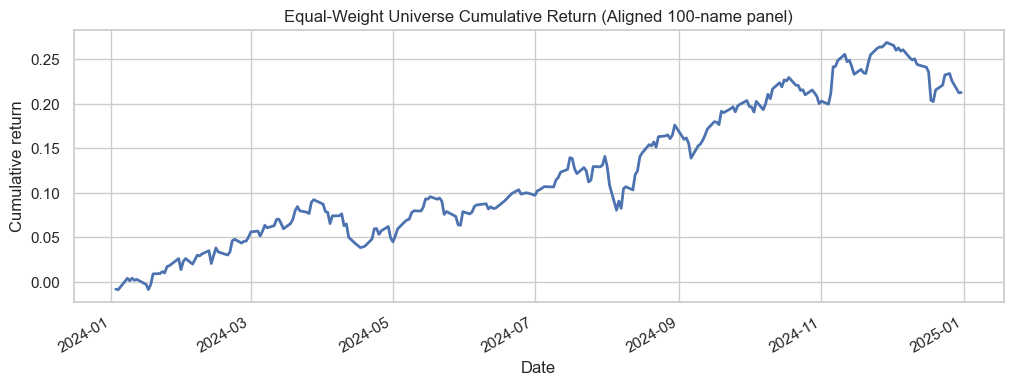

In [5]:
# Universe proxy return: equal-weight daily return of aligned Close series.
close_panel = (
    fts.df["Close"]
    .unstack("Ticker")
    .sort_index()
)

universe_rets = close_panel.pct_change().replace([np.inf, -np.inf], np.nan)
universe_eq_ret = universe_rets.mean(axis=1, skipna=True).dropna().rename("Universe_EQ")
universe_eq_cum = (1.0 + universe_eq_ret).cumprod().rename("Universe_EQ")

fig, ax = plt.subplots(figsize=(12, 4))
(universe_eq_cum - 1.0).plot(ax=ax, color="C0", linewidth=2)
ax.set_title("Equal-Weight Universe Cumulative Return (Aligned 100-name panel)")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
plt.show()


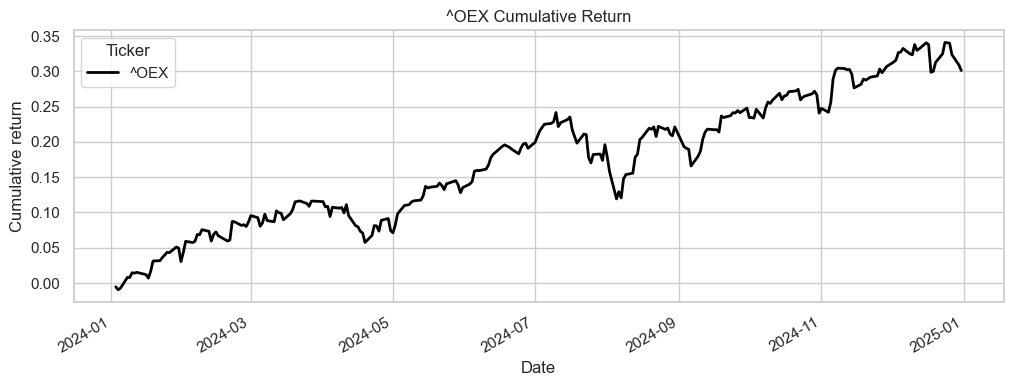

In [6]:
# Benchmark (^OEX) returns from yfinance using same curl_cffi session.
bench_px = yf.download(
    BENCHMARK,
    start=START_DATE,
    end=pd.Timestamp(END_DATE) + pd.Timedelta(days=1),
    auto_adjust=True,
    progress=False,
    session=session,
)

if bench_px.empty:
    raise ValueError("Benchmark download returned empty frame for ^OEX")

bench_close = bench_px["Close"].copy()
bench_close.name = "OEX_Close"
bench_ret = bench_close.pct_change().dropna()
bench_ret.name = "OEX"
bench_cum = (1.0 + bench_ret).cumprod()
bench_cum.name = "OEX"

fig, ax = plt.subplots(figsize=(12, 4))
(bench_cum - 1.0).plot(ax=ax, color="black", linewidth=2)
ax.set_title("^OEX Cumulative Return")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
plt.show()


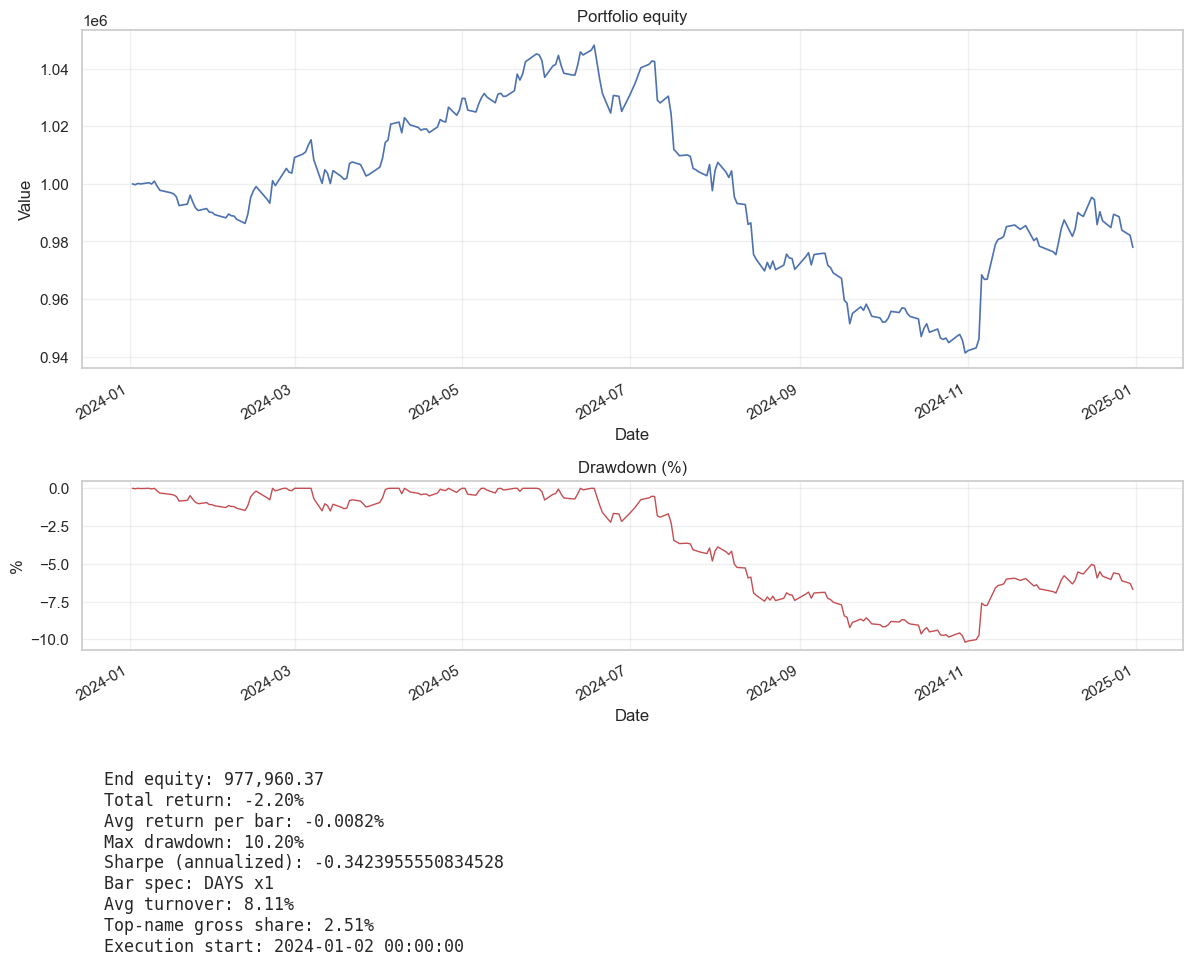

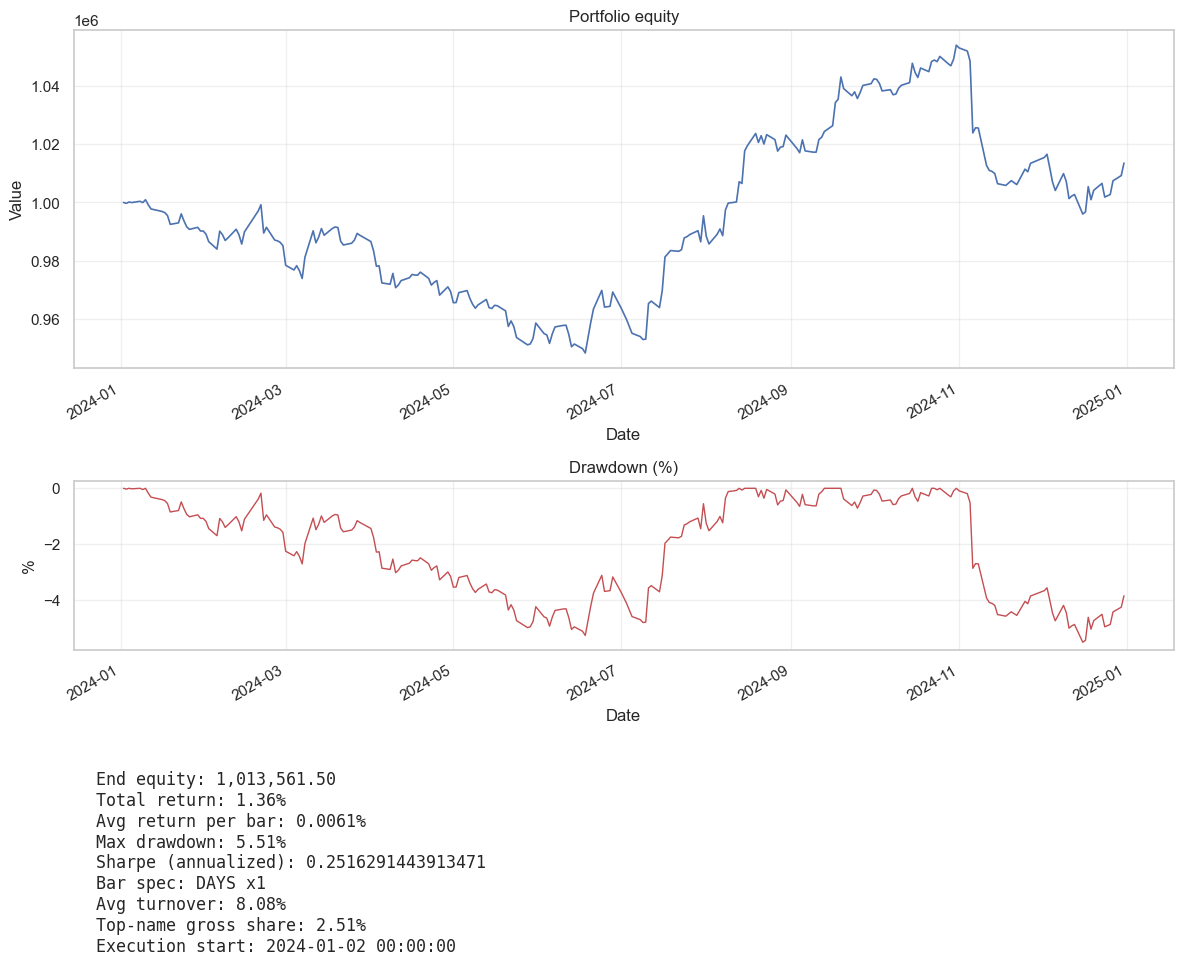

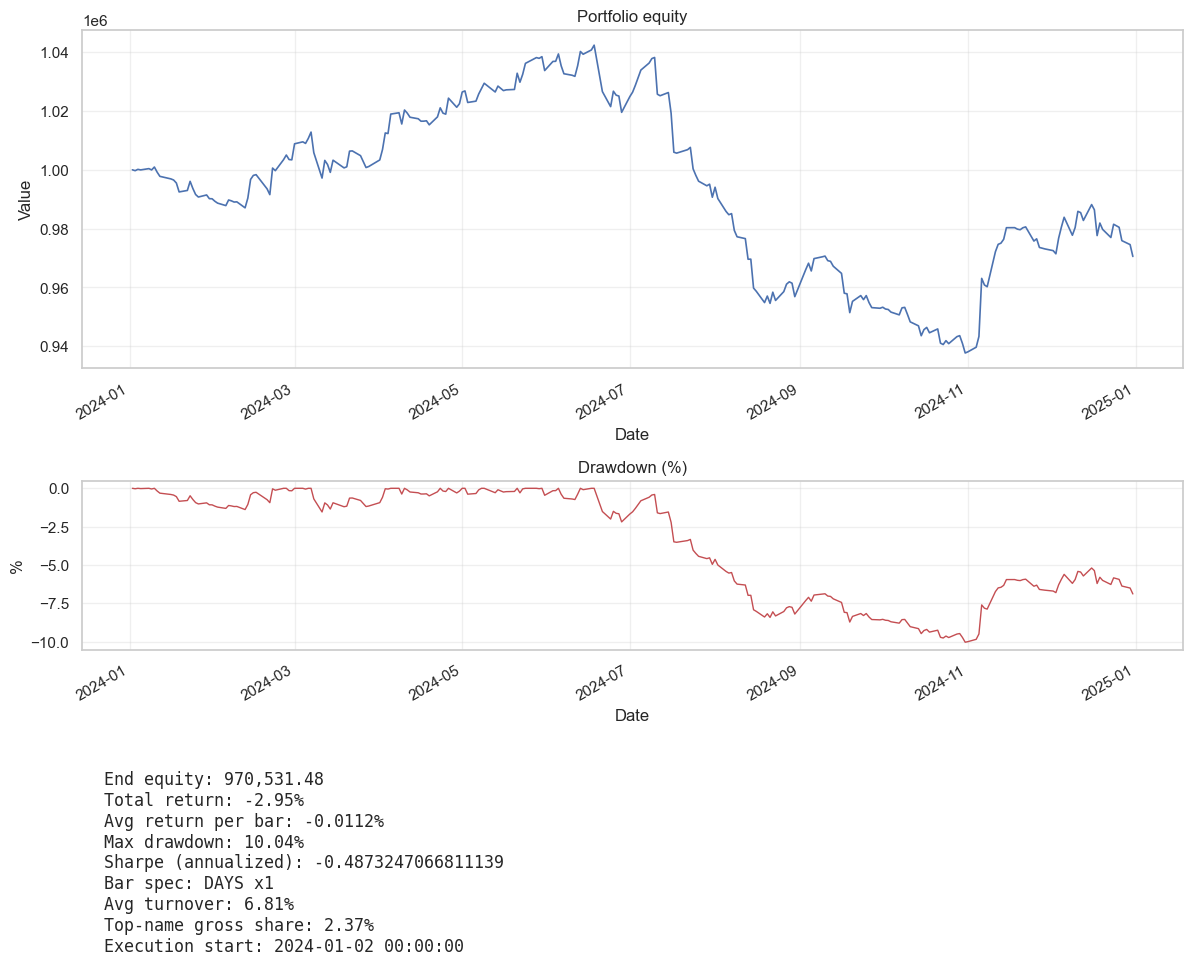

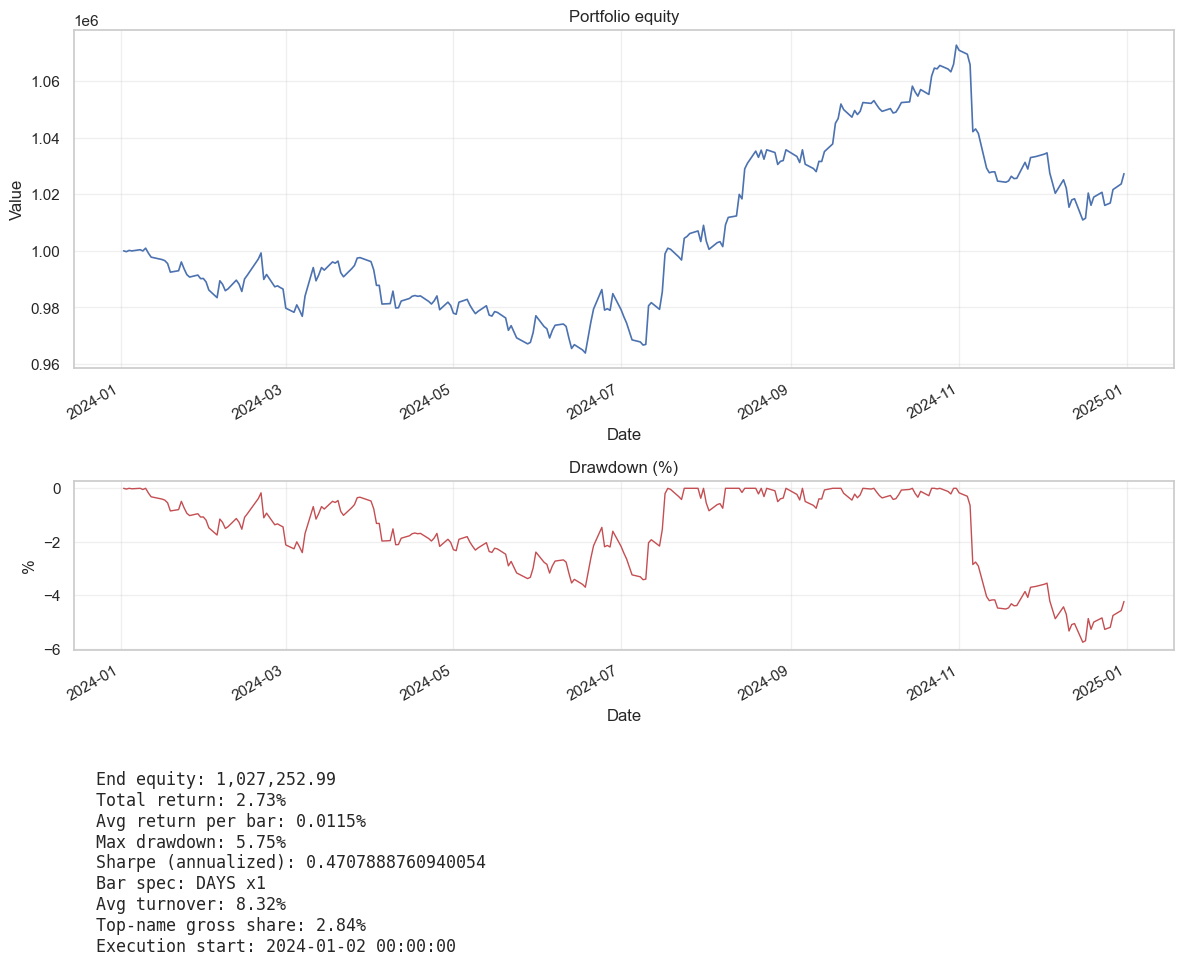

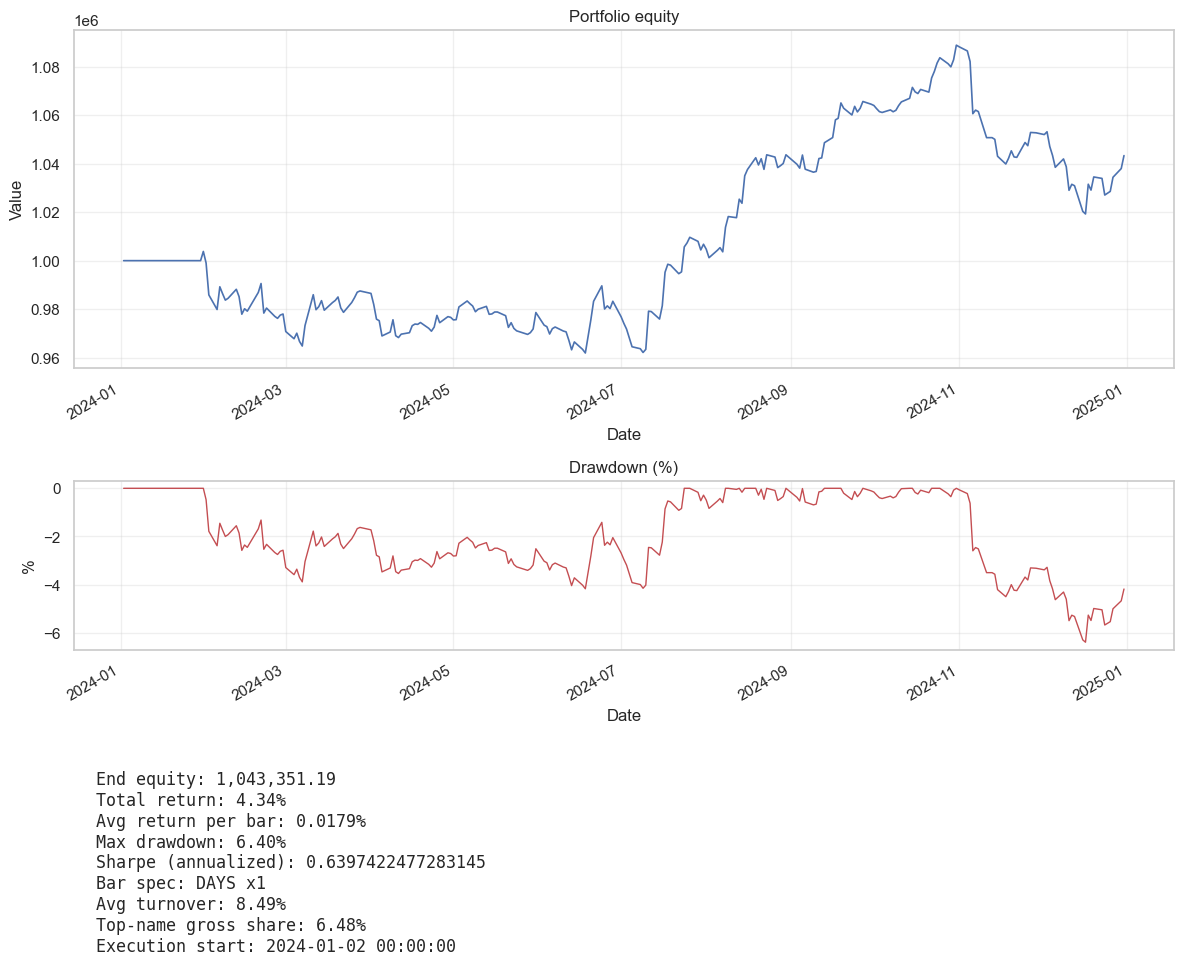

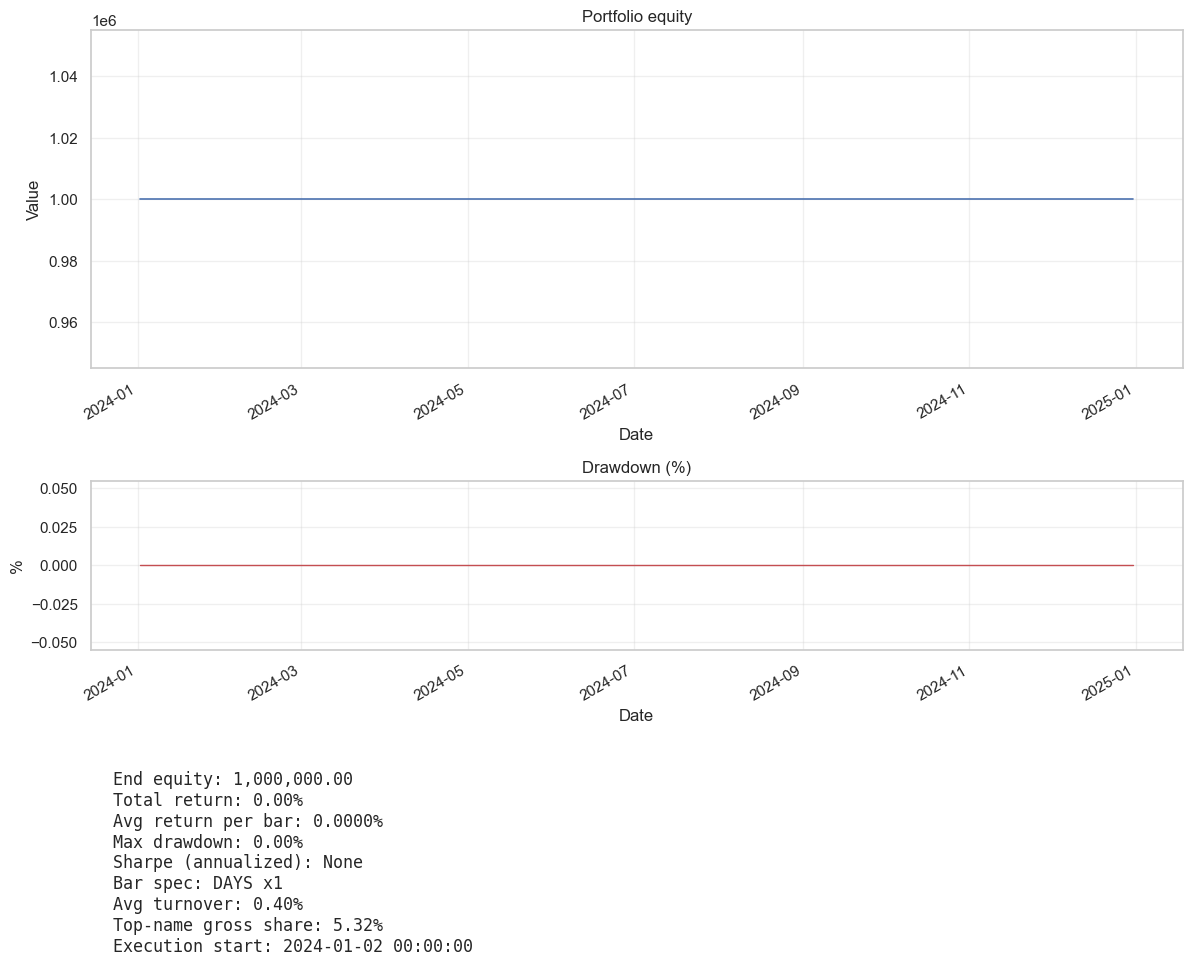

Completed backtests for 6 alphas: ['sma_ratio_20', 'mean_reversion_20', 'breakout_20', 'sma20_deviation_rank', 'sma20_deviation_zscore', 'fundamental_quality_yf']


In [7]:
@dataclass
class AlphaRun:
    name: str
    equity: pd.Series
    returns: pd.Series
    metrics: dict


runs: dict[str, AlphaRun] = {}

for alpha_name, alpha_fn in ALL_ALPHAS.items():
    fs = FinStrat(
        fts,
        alpha_fn,
        neutralization="market",
        truncation=0.01,
        decay_mode="ema",
        decay=0.94,
    )
    bt = FinBT(
        fs,
        fts,
        cash=CASH,
        commission=COMMISSION,
        slippage_pct=SLIPPAGE_PCT,
    ).run()
    out = bt.results(show=True)

    eq = out["equity_curve"]["Equity"].astype(float).rename(alpha_name)
    ret = eq.pct_change().dropna().replace([np.inf, -np.inf], np.nan).dropna().rename(alpha_name)

    runs[alpha_name] = AlphaRun(
        name=alpha_name,
        equity=eq,
        returns=ret,
        metrics=out["metrics"],
    )

print(f"Completed backtests for {len(runs)} alphas: {list(runs.keys())}")


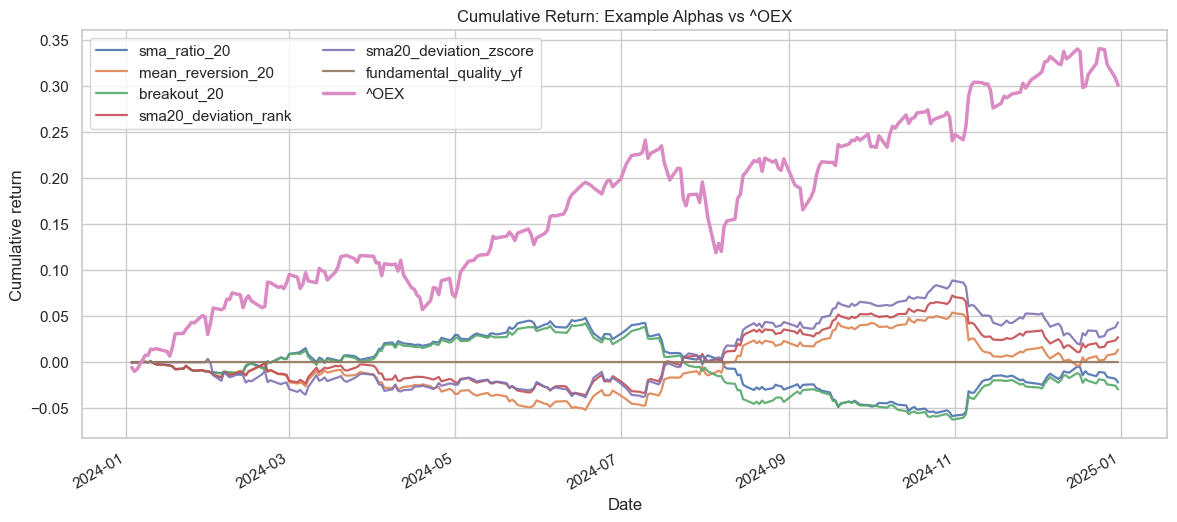

(251, 7)


,sma_ratio_20,mean_reversion_20,breakout_20,sma20_deviation_rank,sma20_deviation_zscore,fundamental_quality_yf,^OEX
Date,,,,,,,
2024-12-24,0.004691,-0.004672,0.004607,-0.004516,-0.006644,0.0,0.012135
2024-12-26,-0.000872,0.000869,-0.001055,0.000811,0.001464,0.0,-0.000668
2024-12-27,-0.004738,0.004711,-0.004626,0.004671,0.005674,0.0,-0.012182
2024-12-30,-0.001803,0.001783,-0.001386,0.001956,0.003467,0.0,-0.011026
2024-12-31,-0.004257,0.004274,-0.004132,0.003544,0.005157,0.0,-0.006036


In [8]:
# Align alpha returns with benchmark and build cumulative returns table.
alpha_returns = pd.concat([r.returns for r in runs.values()], axis=1, join="inner")
all_returns = alpha_returns.join(bench_ret, how="inner").dropna(how="any")

all_cum = (1.0 + all_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
for col in all_cum.columns:
    lw = 2.5 if col == "^OEX" else 1.6
    alpha = 1.0 if col == "^OEX" else 0.9
    all_cum[col].sub(1.0).plot(ax=ax, linewidth=lw, alpha=alpha, label=col)
ax.set_title("Cumulative Return: Example Alphas vs ^OEX")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.legend(loc="best", ncol=2)
plt.show()

print(all_returns.shape)
all_returns.tail()


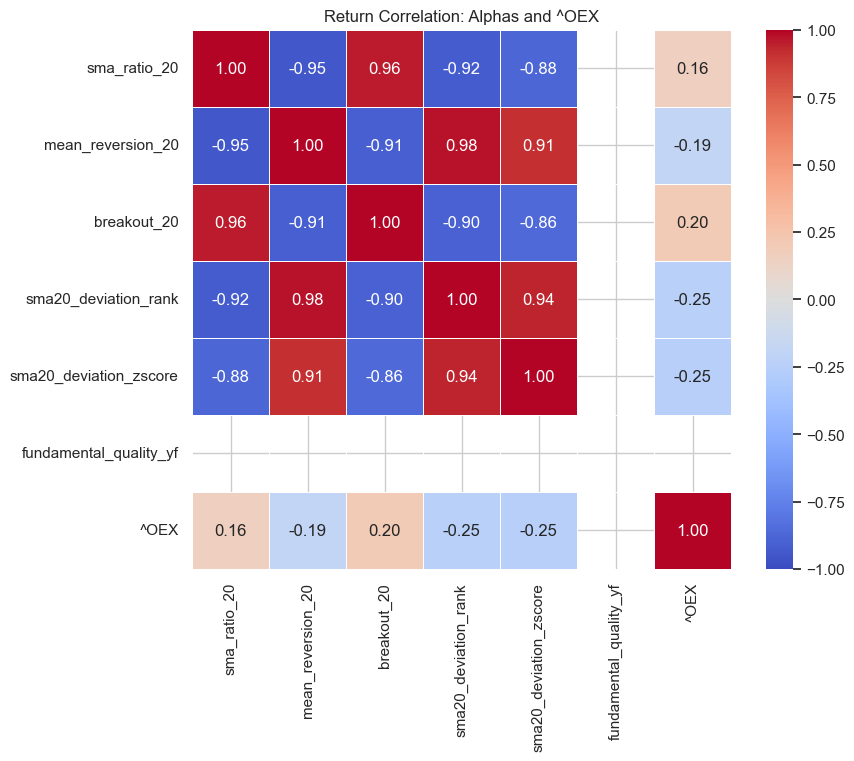

,sma_ratio_20,mean_reversion_20,breakout_20,sma20_deviation_rank,sma20_deviation_zscore,fundamental_quality_yf,^OEX
sma_ratio_20,1.000000,-0.952015,0.958492,-0.924774,-0.875216,NaN,0.157486
mean_reversion_20,-0.952015,1.000000,-0.913978,0.976290,0.909749,NaN,-0.185820
breakout_20,0.958492,-0.913978,1.000000,-0.901161,-0.863060,NaN,0.200873
sma20_deviation_rank,-0.924774,0.976290,-0.901161,1.000000,0.937994,NaN,-0.247810
sma20_deviation_zscore,-0.875216,0.909749,-0.863060,0.937994,1.000000,NaN,-0.251298
fundamental_quality_yf,NaN,NaN,NaN,NaN,NaN,NaN,NaN
^OEX,0.157486,-0.185820,0.200873,-0.247810,-0.251298,NaN,1.000000


In [9]:
# Correlation matrix: all alphas + benchmark.
corr = all_returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Return Correlation: Alphas and ^OEX")
plt.show()

corr


In [10]:
def perf_stats(ret: pd.Series) -> dict:
    ret = ret.dropna()
    if ret.empty:
        return {
            "total_return_pct": np.nan,
            "cagr_pct": np.nan,
            "ann_vol_pct": np.nan,
            "sharpe": np.nan,
            "max_drawdown_pct": np.nan,
        }

    cum = (1.0 + ret).cumprod()
    total_return = cum.iloc[-1] - 1.0
    n_years = max((cum.index[-1] - cum.index[0]).days / 365.25, 1e-9)
    cagr = cum.iloc[-1] ** (1.0 / n_years) - 1.0

    ann_vol = ret.std(ddof=1) * np.sqrt(252)
    sharpe = (ret.mean() / ret.std(ddof=1) * np.sqrt(252)) if ret.std(ddof=1) > 0 else np.nan

    drawdown = cum / cum.cummax() - 1.0
    max_dd = drawdown.min()

    return {
        "total_return_pct": total_return * 100.0,
        "cagr_pct": cagr * 100.0,
        "ann_vol_pct": ann_vol * 100.0,
        "sharpe": sharpe,
        "max_drawdown_pct": max_dd * 100.0,
    }


metric_rows = []
for name in alpha_returns.columns:
    stats = perf_stats(all_returns[name])
    stats["corr_to_oex"] = all_returns[name].corr(all_returns["^OEX"])
    stats["name"] = name
    metric_rows.append(stats)

bench_stats = perf_stats(all_returns["^OEX"])
bench_stats["corr_to_oex"] = 1.0
bench_stats["name"] = "^OEX"
metric_rows.append(bench_stats)

metrics_df = pd.DataFrame(metric_rows).set_index("name").sort_values("sharpe", ascending=False)
metrics_df


,total_return_pct,cagr_pct,ann_vol_pct,sharpe,max_drawdown_pct,corr_to_oex
name,,,,,,
^OEX,30.104977,30.317381,13.834763,1.979869,-9.860209,1.000000
sma20_deviation_zscore,4.335119,4.362567,7.047058,0.639742,-6.397131,-0.251298
sma20_deviation_rank,2.725299,2.742421,6.132425,0.470789,-5.753527,-0.247810
mean_reversion_20,1.356150,1.364613,6.115900,0.251629,-5.510763,-0.185820
sma_ratio_20,-2.203963,-2.217471,6.009821,-0.342396,-10.196705,0.157486
breakout_20,-2.946852,-2.964844,5.816580,-0.487325,-10.044779,0.200873
fundamental_quality_yf,0.000000,0.000000,0.000000,NaN,0.000000,NaN


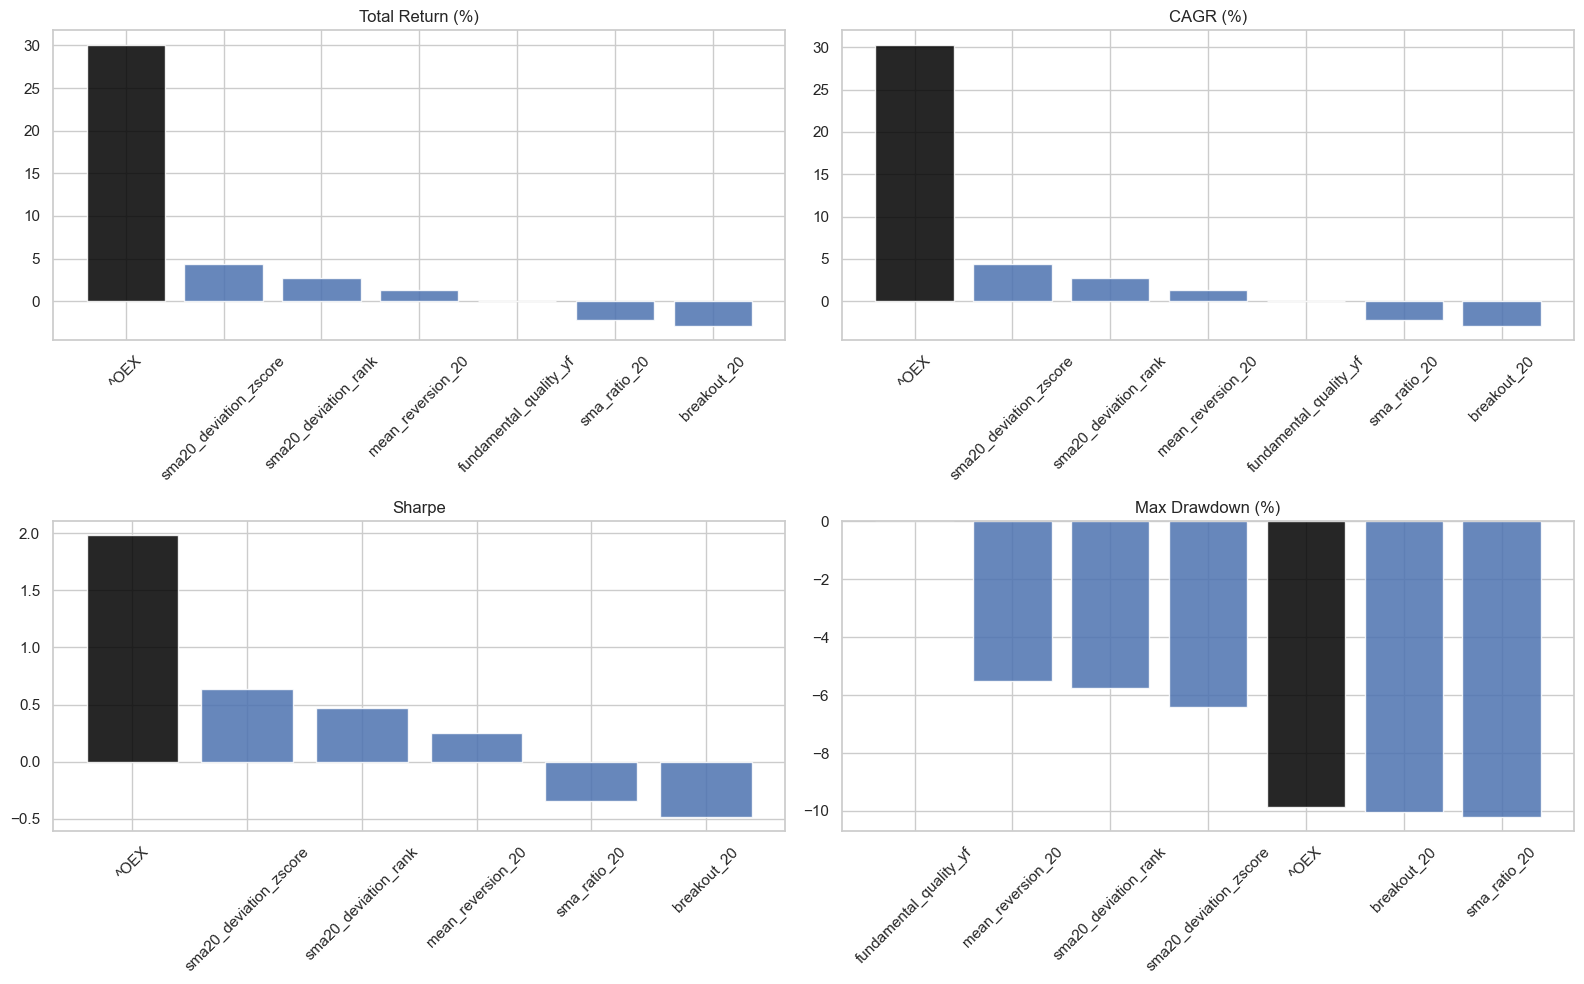

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_specs = [
    ("total_return_pct", "Total Return (%)"),
    ("cagr_pct", "CAGR (%)"),
    ("sharpe", "Sharpe"),
    ("max_drawdown_pct", "Max Drawdown (%)"),
]

for ax, (col, title) in zip(axes.ravel(), plot_specs):
    view = metrics_df[[col]].sort_values(col, ascending=False)
    colors = ["black" if idx == "^OEX" else "C0" for idx in view.index]
    ax.bar(view.index, view[col], color=colors, alpha=0.85)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
